In [ ]:
# Lab 1: Building My Deep Learning Workbench

In [ ]:
#Question A1: In two or three sentences, explain the difference between:
#Git is decentralized and open source. Every developer has a full copy of the repository, and it is hosted locally. Focuses on version control operations like commit, branch, merge, and rebase.
#Github is centralized, owned, and maintained by Microsoft. Repositories are hosted in the cloud, and it manages team collaboration and access control. Focuses on collaboration workflows like pull requests, issues, and code reviews.

In [49]:
print("Hello Deep Learning!")

Hello Deep Learning!


In [ ]:
## Environment

In [50]:
import sys
print(sys.version)
import torch
import numpy as np
import pandas as pd
import matplotlib
print("PyTorch:", torch.__version__)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Matplotlib:", matplotlib.__version__)

3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
PyTorch: 2.11.0+cu128
NumPy: 2.1.3
Pandas: 2.2.3
Matplotlib: 3.10.0


In [ ]:
#Question B1: Why is it useful to record software-library versions when performing machine-learning experiments?
#It is useful for maintaining the ability to reproduce model results when retraining. It also helps with project collaborations and overall better experiment management. Having previous versions helps to understand the model development and the changes introduced by each model version.

In [ ]:
## CPU/GPU

In [51]:
import torch
device = torch.device(
"cuda" if torch.cuda.is_available() else "cpu"
)
print("Selected device:", device)
# If CUDA is available, also run:
if torch.cuda.is_available():
  print(torch.cuda.get_device_name(0))

Selected device: cuda
Tesla T4


In [ ]:
#Question C1: What device is your notebook currently using?
#It was running on the CPU
#Question C2: Why might a GPU be useful when training a large neural network?
#As GPUs have hundreds of times more cores than CPUs, they become a better option to distribute the workflow created by the training of a large neural network.

In [ ]:
## PyTorch Tensors

In [52]:
x = torch.tensor([
[1.0, 2.0, 3.0],
[4.0, 5.0, 6.0]
])
print(x)
#Check its shape:
print(x.shape)
#You should obtain:
#torch.Size([2, 3])
#Now try:
print(x + 10)
print(x * 2)
print(x.mean())

tensor([[1., 2., 3.],
        [4., 5., 6.]])
torch.Size([2, 3])
tensor([[11., 12., 13.],
        [14., 15., 16.]])
tensor([[ 2.,  4.,  6.],
        [ 8., 10., 12.]])
tensor(3.5000)


In [53]:
A = torch.tensor([
[1.0, 2.0],
[3.0, 4.0]
])
B = torch.tensor([
[5.0, 6.0],
[7.0, 8.0]
])
#Calculate:
C = A @ B
print(C)

tensor([[19., 22.],
        [43., 50.]])


In [ ]:
#Question D1: What is the shape of C?
#2x2
#Question D2: Why do you think matrices and tensors might be important in neural networks?
#NN processes the information in data sets by breaking them down into numeric values expressed in matrices and tensors. They are essential.

In [ ]:
## Pretrained Model

In [54]:
x = x.to(device)
print(x.device)

cuda:0


In [55]:
!pip install -q transformers

In [56]:
from transformers import pipeline
# Create an image-classification pipeline:
classifier = pipeline(
"image-classification",
model="google/vit-base-patch16-224"
)

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

In [ ]:
#Questions H1–H4
#Record the following:
#1. What type of model is this?
#A transformer encoder model (BERT-like)
#2. What task was it designed to perform?
#Image classification
#3. What dataset was it trained or fine-tuned on?
#A large collection of images in a supervised fashion at a resolution of 224x224 pixels. The model was fine-tuned on ImageNet, a dataset comprising 1 million images and 1,000 classes, also at resolution 224x224.
#4. What limitations can you identify from the Model Card?
#The 16x16 patch size causes the model to miss small details, which may lead to misclassification.

In [ ]:
## Experiments

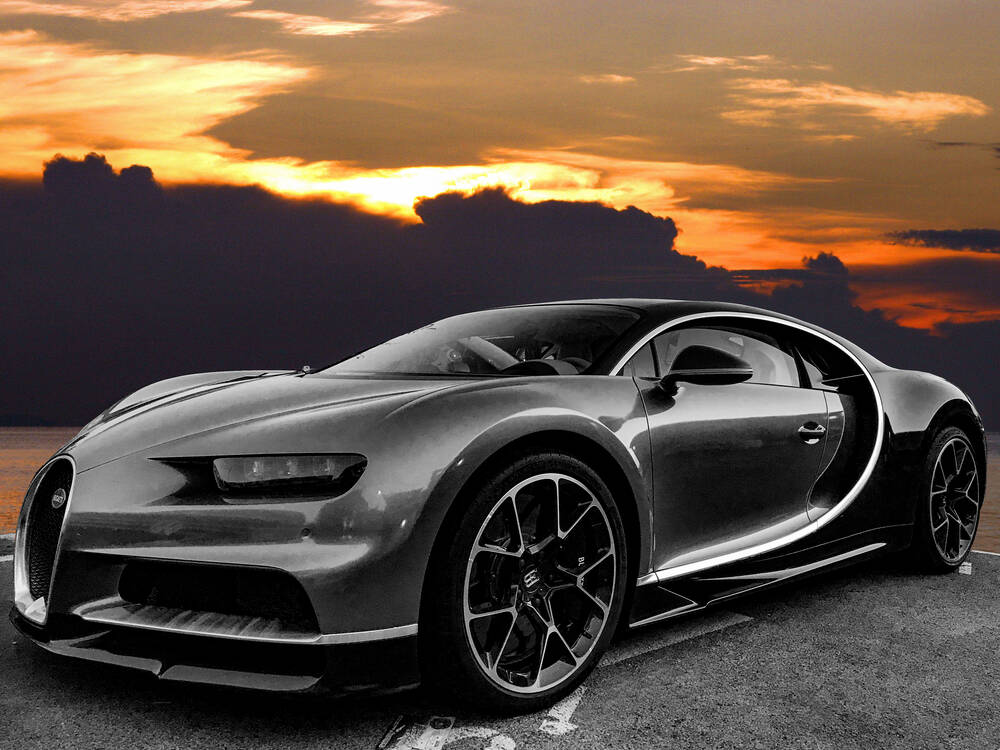

[{'label': 'sports car, sport car', 'score': 0.9492019414901733},
 {'label': 'car wheel', 'score': 0.020996734499931335},
 {'label': 'racer, race car, racing car', 'score': 0.020190728828310966},
 {'label': 'convertible', 'score': 0.00416520144790411},
 {'label': 'grille, radiator grille', 'score': 0.0028419108130037785}]

In [57]:
from PIL import Image
image = Image.open("test-image.jpg")
display(image)
# Run:
results = classifier(image)
results

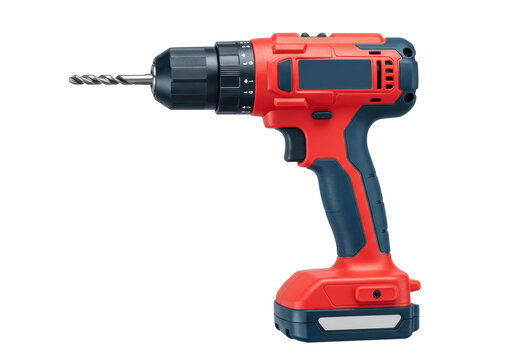

[{'label': 'power drill', 'score': 0.9973692893981934},
 {'label': 'screwdriver', 'score': 0.0007234598742797971},
 {'label': "carpenter's kit, tool kit", 'score': 0.0004701525904238224},
 {'label': 'hammer', 'score': 0.00011444254778325558},
 {'label': 'screw', 'score': 6.88538930262439e-05}]

In [58]:
from PIL import Image
image = Image.open("test-image-drill.jpg")
display(image)
# Run:
results = classifier(image)
results

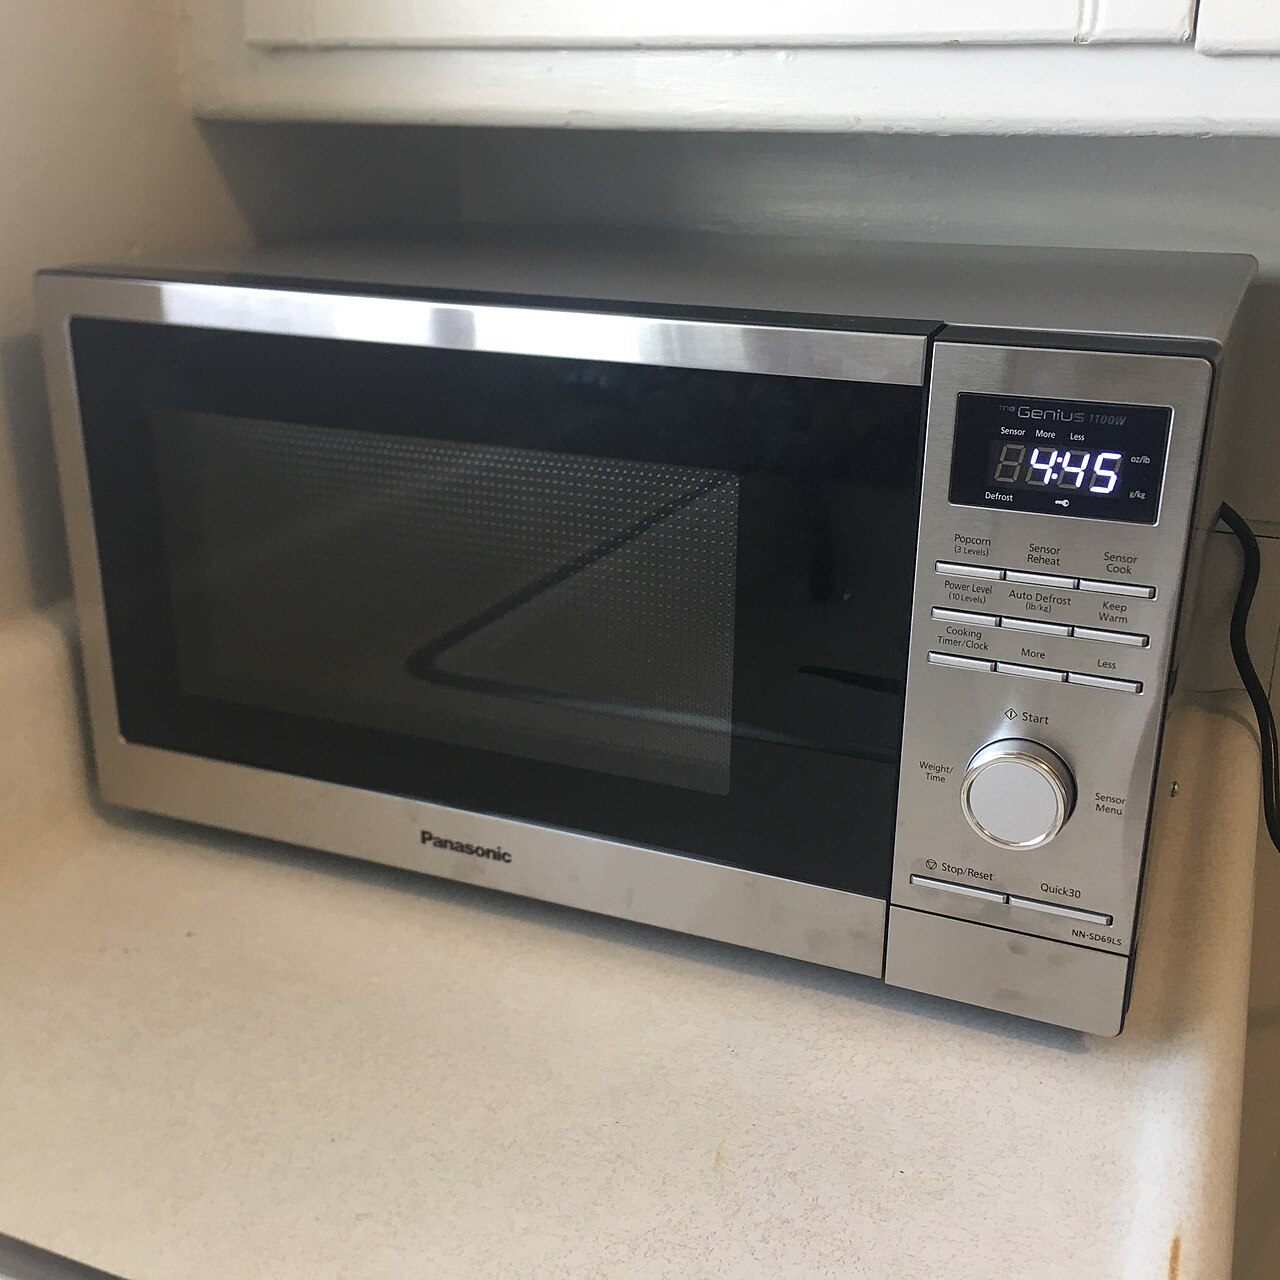

[{'label': 'microwave, microwave oven', 'score': 0.9944924116134644},
 {'label': 'toaster', 'score': 0.0026913939509540796},
 {'label': 'rotisserie', 'score': 0.0007354296976700425},
 {'label': 'dishwasher, dish washer, dishwashing machine',
  'score': 0.00018701529188547283},
 {'label': 'digital clock', 'score': 0.00012088671792298555}]

In [59]:
from PIL import Image
image = Image.open("test-image-microwave.jpg")
display(image)
# Run:
results = classifier(image)
results

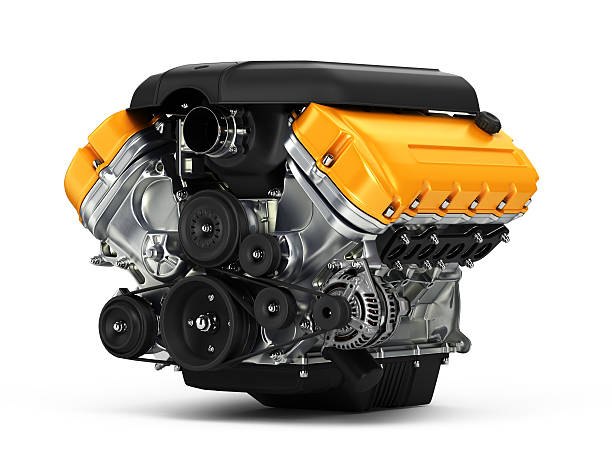

[{'label': 'disk brake, disc brake', 'score': 0.3864825367927551},
 {'label': 'oil filter', 'score': 0.17786894738674164},
 {'label': 'car wheel', 'score': 0.02212093397974968},
 {'label': 'thresher, thrasher, threshing machine',
  'score': 0.02174316719174385},
 {'label': 'electric fan, blower', 'score': 0.013197699561715126}]

In [60]:
from PIL import Image
image = Image.open("test-image-motor.jpg")
display(image)
# Run:
results = classifier(image)
results

In [61]:
import pandas as pd
data = {
    "Image": ["Drill", "Microwave", "Motor"],
    "Prediction 1": ["power drill", "microwave", "disk brake"],
    "Score 1": [0.9974, 0.9945, 0.3865],
    "Prediction 2": ["screwdriver", "toaster", "oil filter"],
    "Score 2": [0.0007, 0.0027, 0.1779],
    "Prediction 3": ["carpenter's kit, tool kit", "rotisserie", "car wheel"],
    "Score 3": [0.0005, 0.0007, 0.0221]
}
df = pd.DataFrame(data)
df

,Image,Prediction 1,Score 1,Prediction 2,Score 2,Prediction 3,Score 3
0,Drill,power drill,0.9974,screwdriver,0.0007,"carpenter's kit, tool kit",0.0005
1,Microwave,microwave,0.9945,toaster,0.0027,rotisserie,0.0007
2,Motor,disk brake,0.3865,oil filter,0.1779,car wheel,0.0221


In [ ]:
## Failure Case

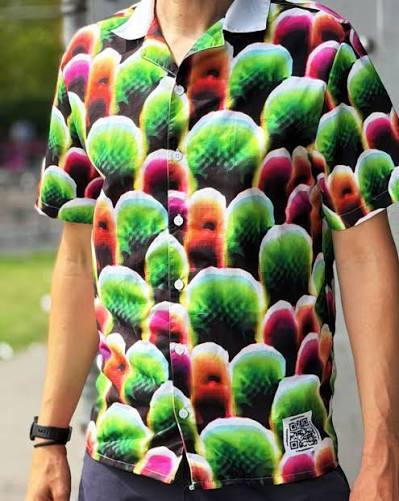

[{'label': 'poncho', 'score': 0.2544955909252167},
 {'label': 'wool, woolen, woollen', 'score': 0.2498973309993744},
 {'label': 'cardigan', 'score': 0.18669231235980988},
 {'label': 'jersey, T-shirt, tee shirt', 'score': 0.06721615791320801},
 {'label': 'bulletproof vest', 'score': 0.026897268369793892}]

In [62]:
from PIL import Image
image = Image.open("test-image-tshirt.jpg")
display(image)
# Run:
results = classifier(image)
results

In [63]:
import pandas as pd
predictions = [
    {'label': 'poncho', 'score': 0.2544955909252167},
    {'label': 'wool, woolen, woollen', 'score': 0.2498973309993744},
    {'label': 'cardigan', 'score': 0.18669231235980988},
    {'label': 'jersey, T-shirt, tee shirt', 'score': 0.06721615791320801},
    {'label': 'bulletproof vest', 'score': 0.026897268369793892}
]
df = pd.DataFrame(predictions)
df.columns = ['Prediction', 'Score']
df['Score'] = df['Score'].round(4)
df

,Prediction,Score
0,poncho,0.2545
1,"wool, woolen, woollen",0.2499
2,cardigan,0.1867
3,"jersey, T-shirt, tee shirt",0.0672
4,bulletproof vest,0.0269


In [ ]:
#Questions K1–K3
#1. What did the model predict?
#Poncho, wool, cardigan,t-shirt, and bulletproof vest
#2. What should the correct interpretation have been?
#T-shirt
#3. Why do you think the model might have failed?
#I chose a wearable that is purposely designed to make classifiers fail. It's designed so AI-powered facial recognition cameras don't work. I think the reason behind this one is the repeated patterns that make it hard for the NN to recognize the detail and depth needed to classify the object.

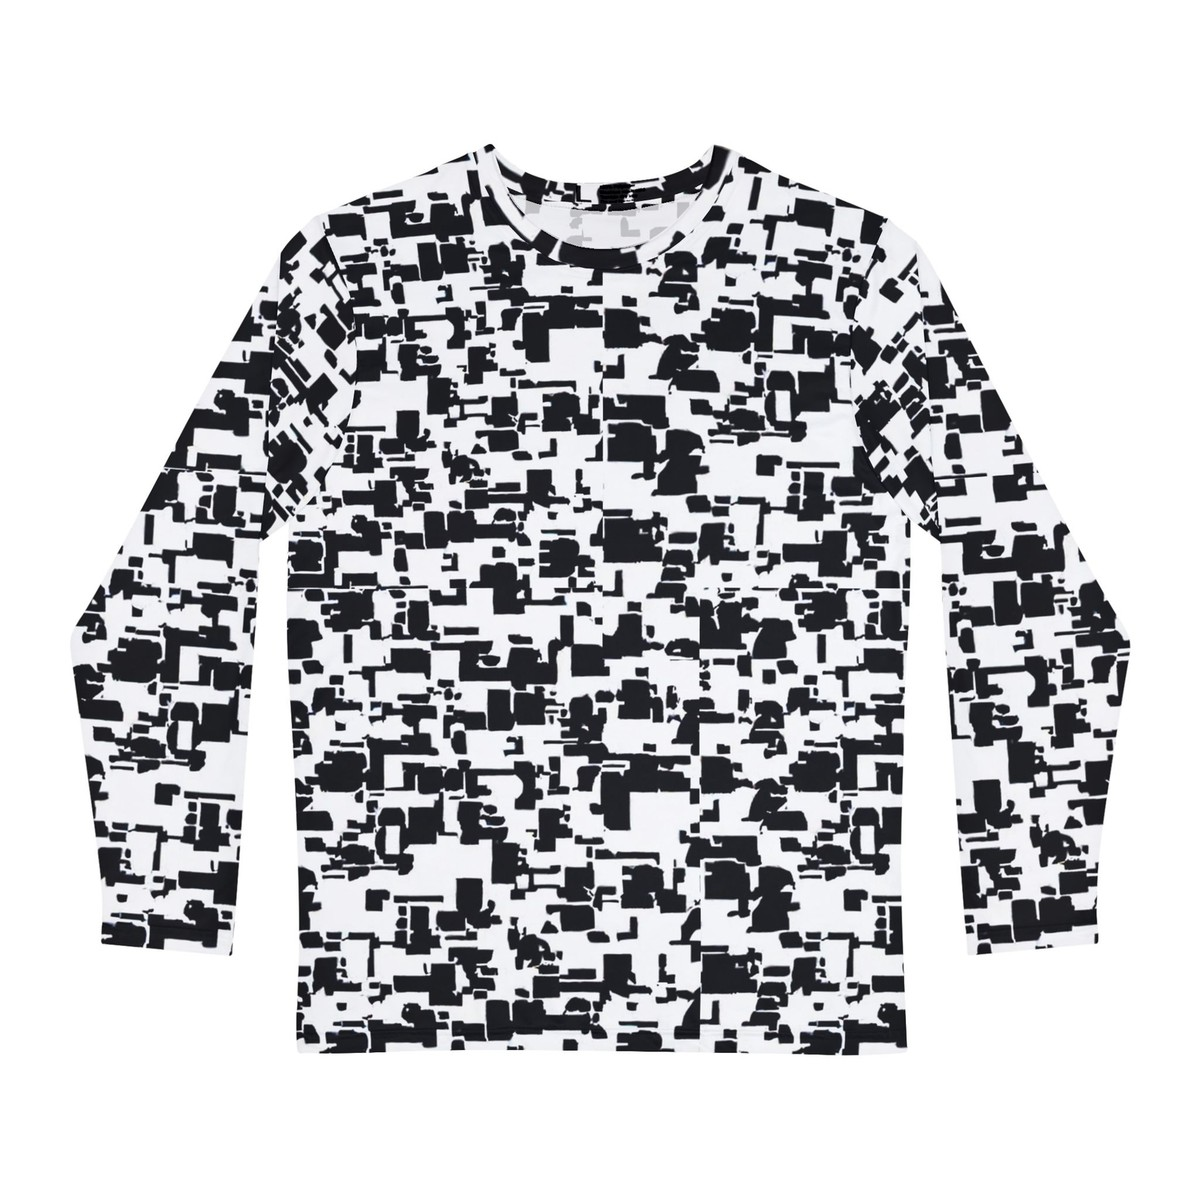

[{'label': 'wool, woolen, woollen', 'score': 0.6651926040649414},
 {'label': 'sweatshirt', 'score': 0.26972371339797974},
 {'label': 'cardigan', 'score': 0.03257821872830391},
 {'label': 'poncho', 'score': 0.0038825487717986107},
 {'label': 'stole', 'score': 0.0033430554904043674}]

In [64]:
from PIL import Image
image = Image.open("test-image-tshirt2.jpg")
display(image)
# Run:
results = classifier(image)
results

In [ ]:
#Question L1: Can you find an example in which the model gives a reasonably high score to an incorrect or questionable prediction?
#Following the wearable line, I chose another anti-facial recognition tshirt for which the model gives a P(wool)=0.665 as the first prediction, and also incorrectly predicts the other four guesses.

In [65]:
import pandas as pd
predictions = [
    {'label': 'wool, woolen, woollen', 'score': 0.6651926040649414},
    {'label': 'sweatshirt', 'score': 0.26972371339797974},
    {'label': 'cardigan', 'score': 0.03257821872830391},
    {'label': 'poncho', 'score': 0.0038825487717986107},
    {'label': 'stole', 'score': 0.0033430554904043674}
]
df = pd.DataFrame(predictions)
df.columns = ['Prediction', 'Score']
df['Score'] = df['Score'].round(4)
df

,Prediction,Score
0,"wool, woolen, woollen",0.6652
1,sweatshirt,0.2697
2,cardigan,0.0326
3,poncho,0.0039
4,stole,0.0033


In [ ]:
## Reflection

In [ ]:
# Classifiers may be useful in processes or environments that require the fast classification of enormous amounts of data, and where a false positive or false negative doesn't have immoral or dangerous consequences. As shown through these experiments, even though well-trained classifiers have high accuracies, they are not perfect and will fail sometimes. It is important to ensure that these failures are not prejudicial to society.